In [1]:
import os
import glob
import geopandas as gpd
import rasterio
from rasterio.mask import mask

In [ ]:
# -----------------------------------------------------------------------------
# Define file paths
# -----------------------------------------------------------------------------
# Folder containing the raster files
raster_dir = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/"

# Folder containing the geopackage and the geopackage file name
gpkg_dir = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/polygons/"
gpkg_filename = "cluster_eobs_franken.gpkg"
gpkg_path = os.path.join(gpkg_dir, gpkg_filename)

# -----------------------------------------------------------------------------
# Read the geopackage file
# -----------------------------------------------------------------------------
# Load all features from the geopackage into a GeoDataFrame.
# The file is expected to have at least two columns: 'fid' and 'layer'.
gdf = gpd.read_file(gpkg_path)
if 'layer' not in gdf.columns:
    raise ValueError("The geopackage does not have a 'layer' column.")

# -----------------------------------------------------------------------------
# List the TIFF files starting with "extentFranken"
# -----------------------------------------------------------------------------
tif_files = glob.glob(os.path.join(raster_dir, "extentFranken*.tif"))

if not tif_files:
    print("No TIFF files starting with 'extentFranken' were found.")
    exit()

# -----------------------------------------------------------------------------
# Process each TIFF file
# -----------------------------------------------------------------------------
for tif_file in tif_files:
    print(f"Processing raster: {tif_file}")
    
    # Open the raster file (which may have multiple bands)
    with rasterio.open(tif_file) as src:
        
        # Determine an appropriate nodata value.
        # If the raster does not have a nodata value or it is 0,
        # we assign a new value (e.g., -9999) so that the masked areas
        # will not be confused with valid data.
        nodata_val = src.nodata
        if nodata_val is None or nodata_val == 0:
            nodata_val = -9999

        # Loop over each polygon feature in the GeoDataFrame.
        # Each feature (row) is expected to have a geometry and a 'layer' value.
        for idx, feature in gdf.iterrows():
            geom = feature.geometry
            layer_name = feature['layer']

            # If the coordinate systems differ, reproject the polygon to match the raster.
            if gdf.crs != src.crs:
                geom = gpd.GeoSeries([geom], crs=gdf.crs).to_crs(src.crs).iloc[0]
            
            # Clip the raster with the polygon geometry.
            # The nodata parameter is set to nodata_val so that areas outside the
            # polygon will be filled with this nodata value (and not with 0).
            try:
                out_image, out_transform = mask(src, [geom], crop=True, nodata=nodata_val)
            except Exception as e:
                print(f"Error clipping {tif_file} with polygon {layer_name}: {e}")
                continue

            # Update the metadata for the output file.
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": nodata_val
            })

            # Create an output filename that inserts the polygon layer name.
            # For example, if the original file is:
            #   extentFranken_2016_mean_100m.tif
            # and layer_name is "Cl8", then the output file will be:
            #   extentFranken_Cl8_2016_mean_100m.tif
            base_name = os.path.basename(tif_file)
            if base_name.startswith("extentFranken"):
                new_filename = base_name.replace("extentFranken", f"extentFranken_{layer_name}", 1)
            else:
                new_filename = f"{layer_name}_{base_name}"
            
            out_path = os.path.join(raster_dir, new_filename)

            # Write the clipped raster to a new TIFF file.
            with rasterio.open(out_path, "w", **out_meta) as dest:
                dest.write(out_image)
            
            print(f"Saved clipped raster: {out_path}")

In [4]:
import os
import geopandas as gpd
import xarray as xr
import rioxarray

# -----------------------------------------------------------------------------
# Define file paths and directories
# -----------------------------------------------------------------------------
# Input NetCDF file directory (hard-coded)
raster_dir = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/"
# Change this filename to your selected input NetCDF file
nc_file = os.path.join(raster_dir, "extentFranken_20152017_100m.nc")

# Output directory for the clipped NetCDF files
output_dir = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Geopackage file containing the clipping polygons
gpkg_dir = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/polygons/"
gpkg_filename = "cluster_eobs_franken.gpkg"
gpkg_path = os.path.join(gpkg_dir, gpkg_filename)

# -----------------------------------------------------------------------------
# Read the geopackage file
# -----------------------------------------------------------------------------
gdf = gpd.read_file(gpkg_path)
if "layer" not in gdf.columns:
    raise ValueError("The geopackage does not have a 'layer' column.")

# -----------------------------------------------------------------------------
# Open the NetCDF file as an xarray DataArray and assign CRS using rioxarray
# -----------------------------------------------------------------------------

if not os.path.exists(nc_file):
    print(f"The file {nc_file} does not exist. Exiting.")
    exit()

print(f"Processing NetCDF: {nc_file}")

# Depending on how your NetCDF is structured, you may either have a DataArray
# or a Dataset containing the DataArray. Here we assume the file contains a
# single DataArray named "Spectral_Temporal_Stack". If not, adjust accordingly.
ds = xr.open_dataset(nc_file)
da = ds.Spectral_Temporal_Stack

# If your input file contains CRS info in the attributes under "grid_mapping"
# (with a key "spatial_ref"), extract and write it to the DataArray.
if "grid_mapping" in da.attrs:
    
    crs_value = da.y.crs
    da = da.rio.write_crs(crs_value)
    
else:
    print("Warning: No 'grid_mapping' attribute found in the NetCDF file. CRS may be missing.")

# -----------------------------------------------------------------------------
# Select only the "ndvi" and "ndwi" bands
# -----------------------------------------------------------------------------
# It is assumed that the "band" coordinate contains string labels including
# "ndvi" and "ndwi". Adjust the selection if your bands are indexed differently.
try:
    da = da.sel(band=["ndvi", "ndwi"])
except Exception as e:
    raise ValueError(f"Error selecting 'ndvi' and 'ndwi' bands: {e}")

# -----------------------------------------------------------------------------
# Loop over each polygon feature and clip the DataArray
# -----------------------------------------------------------------------------
for idx, feature in gdf.iterrows():
    geom = feature.geometry
    layer_name = feature["layer"]

    # If the coordinate systems differ, reproject the polygon to match the DataArray's CRS.
    if gdf.crs != da.rio.crs:
        geom = gpd.GeoSeries([geom], crs=gdf.crs).to_crs(da.rio.crs).iloc[0]

    # Clip the DataArray using rioxarray's clip. The polygon geometry must be
    # passed as a list.
    try:
        clipped_da = da.rio.clip([geom], crs=da.rio.crs, drop=True)
    except Exception as e:
        print(f"Error clipping {nc_file} with polygon {layer_name}: {e}")
        continue

    # (Optional) Reassign the CRS to the clipped DataArray so it is stored in the output.
    clipped_da = clipped_da.rio.write_crs(da.rio.crs)

    # Create an output filename that inserts the polygon layer name.
    base_name = os.path.basename(nc_file)
    base_no_ext = os.path.splitext(base_name)[0]
    new_filename = f"{base_no_ext}_{layer_name}.nc"
    out_path = os.path.join(output_dir, new_filename)

    # Save the clipped DataArray as a NetCDF file
    clipped_da.to_netcdf(out_path)
    print(f"Saved clipped NetCDF: {out_path}")


Processing NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/extentFranken_20152017_100m.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl0a.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl0b.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl1.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl2.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl3.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl4.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/extentFranken_20152017_100m_Cl5_6_7.nc
Saved clipped NetCDF: /dss/dsstbyfs02/pr9

In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
import xarray as xr
#sns.set(style="darkgrid")
#sns.set(style="whitegrid")
#sns.set_style("white")
sns.set(style="whitegrid",font_scale=2)
import matplotlib.collections as clt
import sys
sys.path.append('../ptitprince/')
import ptitprince as pt
import re

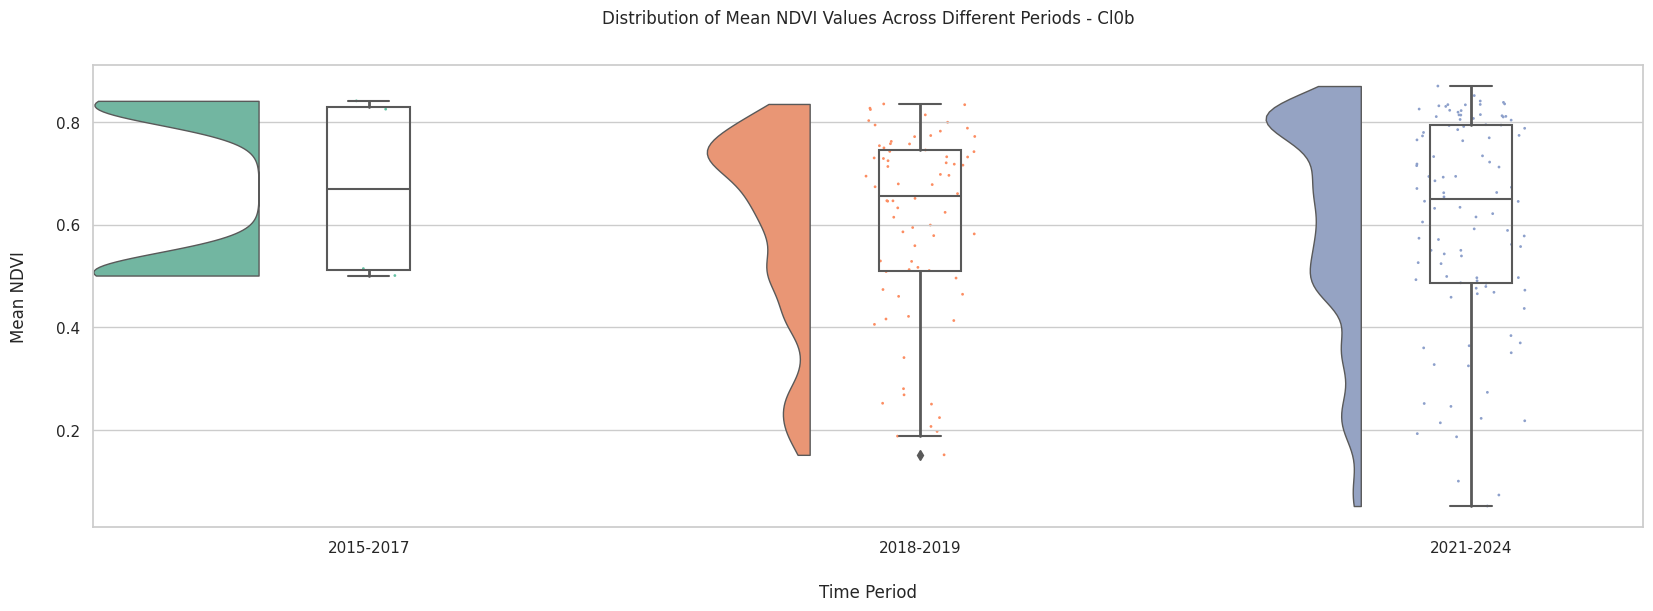

Plot saved successfully at: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/graphs/mean_ndvi_Cl0b_distribution.png


In [4]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt  # assuming ptitprince is installed and imported as pt
import os

# Dynamic variables
band = 'ndvi'
stat = 'mean'
file_id = "Cl0b"  # <-- Change only this to update all file paths

# Base path for datasets
base_path = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/"

# Define dataset file paths dynamically
file_path1 = f"{base_path}extentFranken_20152017_100m_{file_id}.nc"
file_path2 = f"{base_path}extentFranken_20182019_100m_{file_id}.nc"
file_path3 = f"{base_path}extentFranken_20212024_100m_{file_id}.nc"

# Open the datasets
ds1 = xr.open_dataset(file_path1)
ds2 = xr.open_dataset(file_path2)
ds3 = xr.open_dataset(file_path3)

# Select the data arrays
da1 = ds1.Spectral_Temporal_Stack
da2 = ds2.Spectral_Temporal_Stack
da3 = ds3.Spectral_Temporal_Stack

# Dynamically select the band of interest
da_sel1 = da1.sel(band=band)
da_sel2 = da2.sel(band=band)
da_sel3 = da3.sel(band=band)

# Compute the statistic dynamically (e.g., mean, median, etc.) over spatial dimensions
group1 = getattr(da_sel1, stat)(dim=("y", "x"))
group2 = getattr(da_sel2, stat)(dim=("y", "x"))
group3 = getattr(da_sel3, stat)(dim=("y", "x"))

# Convert xarray.DataArray objects to pandas Series and label them by period
series1 = pd.Series(group1.values, name='2015-2017')
series2 = pd.Series(group2.values, name='2018-2019')
series3 = pd.Series(group3.values, name='2021-2024')

# Create a dynamic label for the computed values (e.g., "Mean NDVI")
value_label = f"{stat.capitalize()} {band.upper()}"

# Combine the Series into a single DataFrame and melt it for plotting
df = pd.concat([series1, series2, series3], axis=1).melt(var_name='Period', value_name=value_label)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Initialize the figure
plt.figure(figsize=(20, 6))

# Create the raincloud plot using the dynamic value label for the y-axis
pt.RainCloud(x='Period', y=value_label, data=df, orient='v', width_viol=0.6, point_size=2, palette="Set2")

# Add title and labels with padding
plt.title(f'Distribution of {value_label} Values Across Different Periods - {file_id}', pad=30)
plt.xlabel('Time Period', labelpad=20)
plt.ylabel(value_label, labelpad=20)

# Define the output folder and dynamically generate the filename
output_folder = f"{base_path}graphs/"
os.makedirs(output_folder, exist_ok=True)  # Ensure the folder exists

output_filename = f"{output_folder}{stat}_{band}_{file_id}_distribution.png"

# Save the figure as a PNG with 300 dpi
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print(f"Plot saved successfully at: {output_filename}")


In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt  # Assuming ptitprince is installed
import os

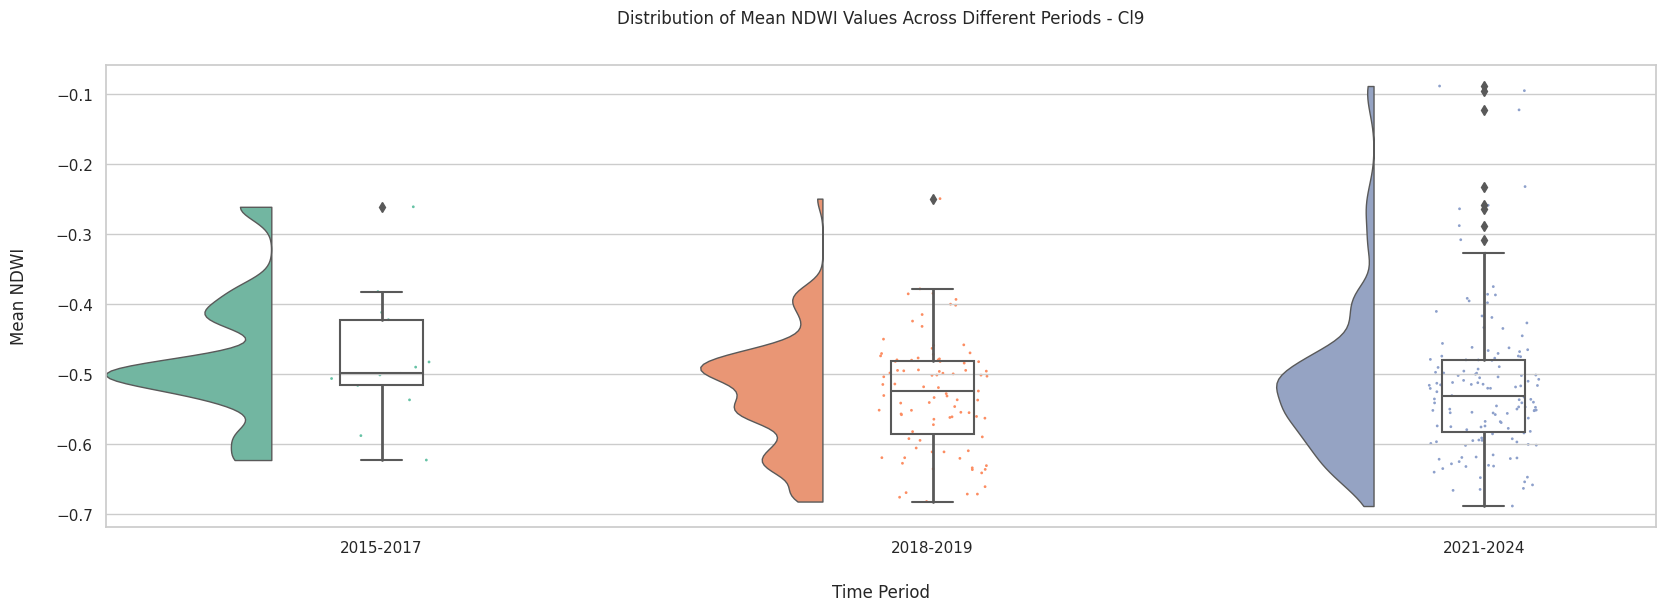

Plot saved successfully at: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/graphs/mean_ndwi_Cl9_distribution.png


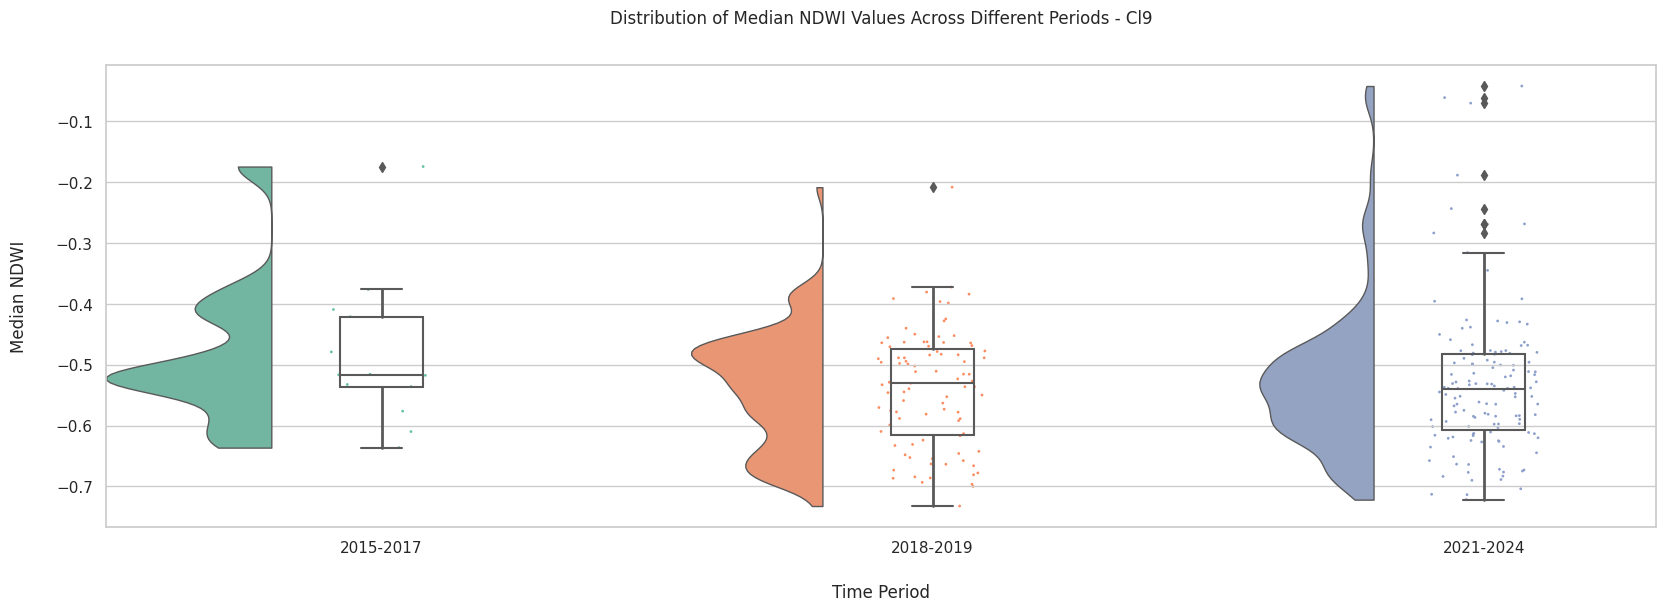

Plot saved successfully at: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/graphs/median_ndwi_Cl9_distribution.png


/dss/dsstbyfs01/pn56su/pn56su-dss-0020/opt/miniconda3/23.3.1/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/dss/dsstbyfs01/pn56su/pn56su-dss-0020/opt/miniconda3/23.3.1/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/dss/dsstbyfs01/pn56su/pn56su-dss-0020/opt/miniconda3/23.3.1/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


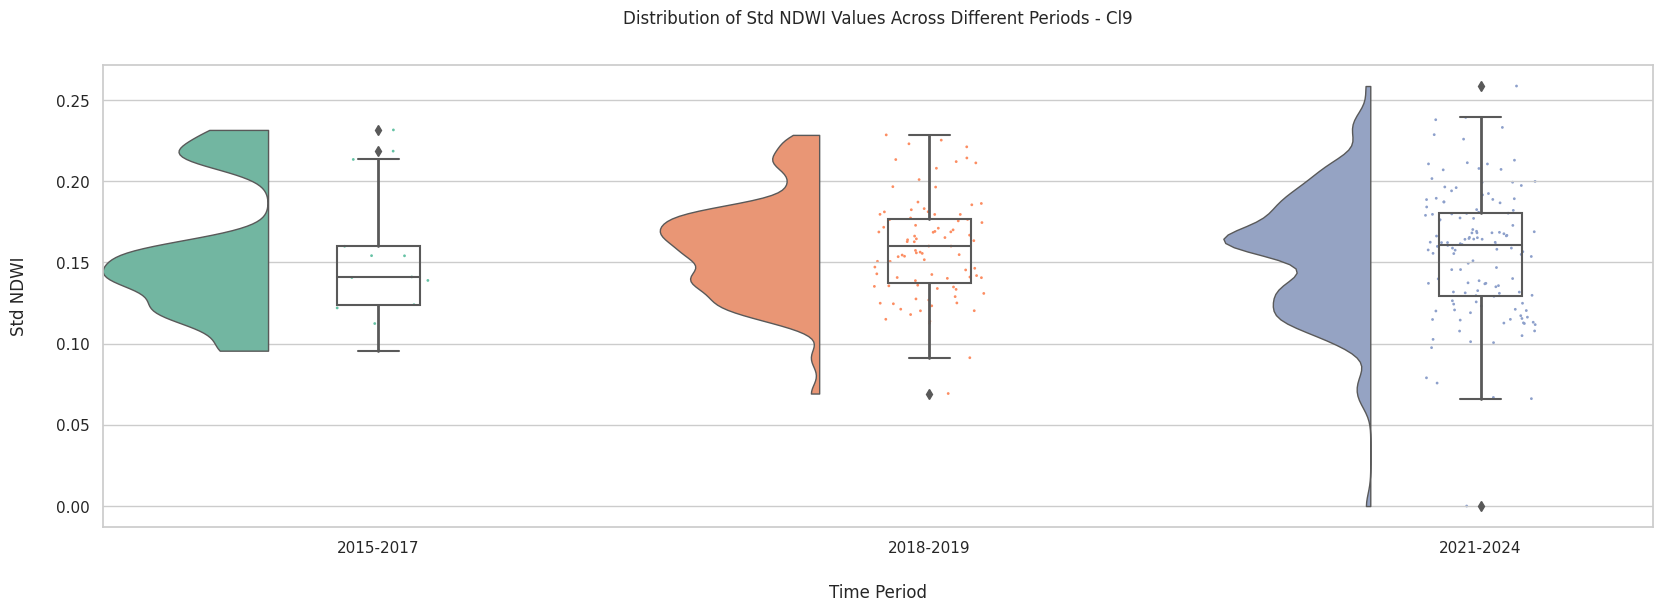

Plot saved successfully at: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/graphs/std_ndwi_Cl9_distribution.png


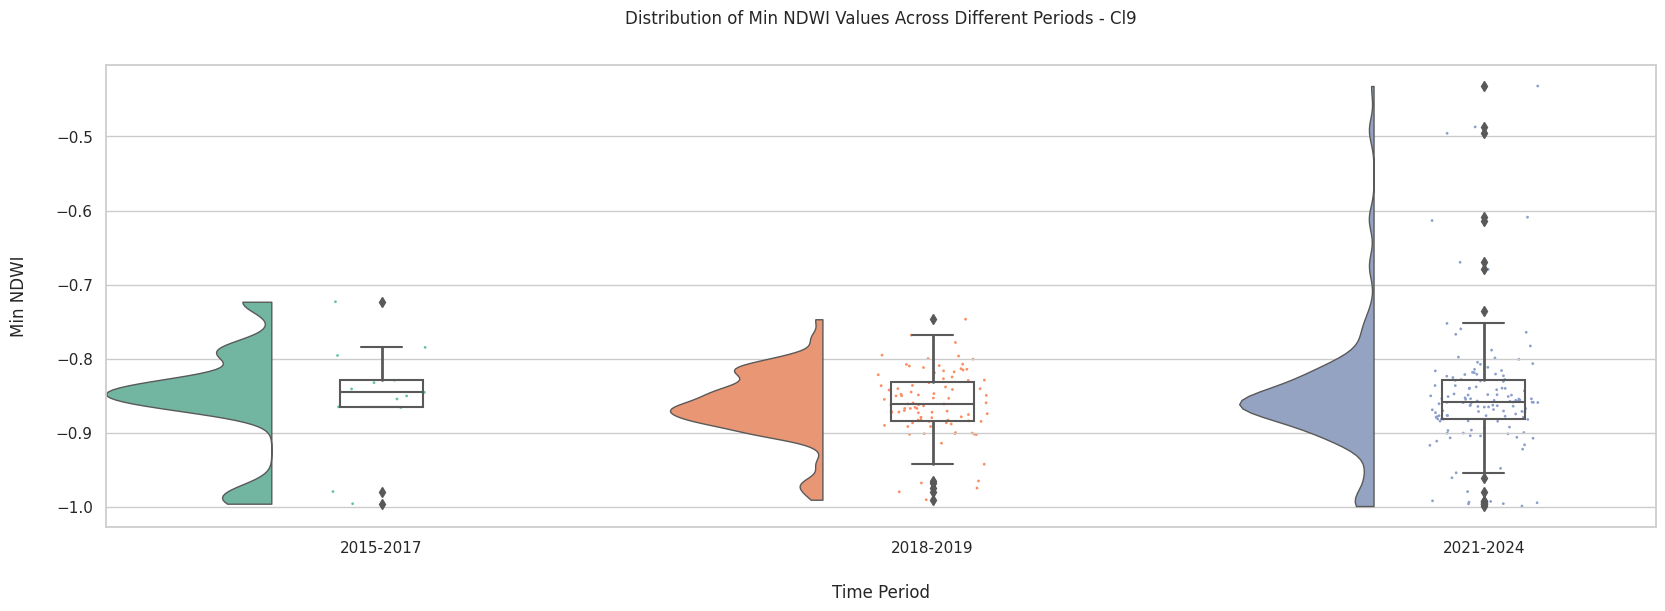

Plot saved successfully at: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/graphs/min_ndwi_Cl9_distribution.png


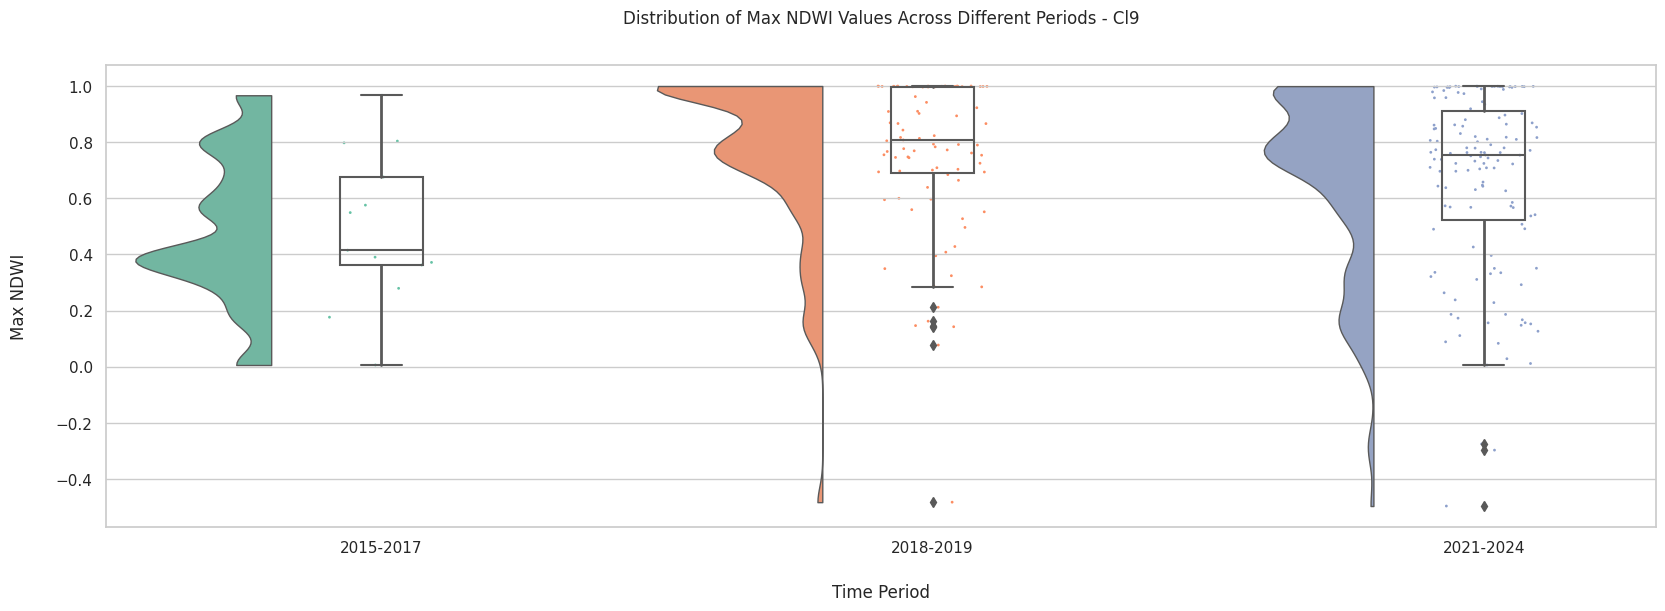

Plot saved successfully at: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/graphs/max_ndwi_Cl9_distribution.png


In [9]:
# Dynamic variables
stats = ["mean", "median", "std", "min", "max"]  # List of statistics

band = 'ndvi'
file_id = "Cl9"  # Change this to update all file paths

# Base path for datasets
base_path = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/franken/"

# Define dataset file paths dynamically
file_path1 = f"{base_path}extentFranken_20152017_100m_{file_id}.nc"
file_path2 = f"{base_path}extentFranken_20182019_100m_{file_id}.nc"
file_path3 = f"{base_path}extentFranken_20212024_100m_{file_id}.nc"

# Open the datasets
ds1 = xr.open_dataset(file_path1)
ds2 = xr.open_dataset(file_path2)
ds3 = xr.open_dataset(file_path3)

# Select the data arrays
da1 = ds1.Spectral_Temporal_Stack
da2 = ds2.Spectral_Temporal_Stack
da3 = ds3.Spectral_Temporal_Stack

# Dynamically select the band of interest
da_sel1 = da1.sel(band=band)
da_sel2 = da2.sel(band=band)
da_sel3 = da3.sel(band=band)

# Define the output folder
output_folder = f"{base_path}graphs/"
os.makedirs(output_folder, exist_ok=True)  # Ensure the folder exists

# Loop through each statistic and generate plots
for stat in stats:
    # Compute the statistic dynamically (e.g., mean, median, etc.)
    group1 = getattr(da_sel1, stat)(dim=("y", "x"))
    group2 = getattr(da_sel2, stat)(dim=("y", "x"))
    group3 = getattr(da_sel3, stat)(dim=("y", "x"))

    # Convert xarray.DataArray objects to pandas Series and label them by period
    series1 = pd.Series(group1.values, name='2015-2017')
    series2 = pd.Series(group2.values, name='2018-2019')
    series3 = pd.Series(group3.values, name='2021-2024')

    # Create a dynamic label for the computed values (e.g., "Mean NDVI")
    value_label = f"{stat.capitalize()} {band.upper()}"

    # Combine the Series into a single DataFrame and melt it for plotting
    df = pd.concat([series1, series2, series3], axis=1).melt(var_name='Period', value_name=value_label)

    # Set the aesthetic style of the plots
    sns.set(style="whitegrid")

    # Initialize the figure
    plt.figure(figsize=(20, 6))

    # Create the raincloud plot using the dynamic value label for the y-axis
    pt.RainCloud(x='Period', y=value_label, data=df, orient='v', width_viol=0.6, point_size=2, palette="Set2")

    # Add title and labels with padding
    plt.title(f'Distribution of {value_label} Values Across Different Periods - {file_id}', pad=30)
    plt.xlabel('Time Period', labelpad=20)
    plt.ylabel(value_label, labelpad=20)

    # Generate a unique output filename for each statistic
    output_filename = f"{output_folder}{stat}_{band}_{file_id}_distribution.png"

    # Save the figure as a PNG with 300 dpi
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()

    print(f"Plot saved successfully at: {output_filename}")
